# Results Section — Machine-Generated Code Detection
**Team Tech Titans | SemEval-2026 Task 13 | IIIT Hyderabad**

This notebook produces all figures and tables for the **Results & Discussion** section of the final report.

Run cells top to bottom. All figures saved as `.png`, summary saved as `.txt`.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from IPython.display import display
import warnings, os
warnings.filterwarnings('ignore')

HUMAN_CLR   = '#4CAF50'
MACHINE_CLR = '#E53935'
OOD_CLR     = '#FF9800'
SEEN_CLR    = '#1976D2'
BEST_CLR    = '#6A1B9A'

os.makedirs('results_output', exist_ok=True)
print('Setup done. All outputs will be saved to results_output/')

Setup done. All outputs will be saved to results_output/


---
## Table 1 — Main Results (All Models, In-Distribution vs OOD)

In [2]:
# ── All real numbers from your experiments ───────────────────────────────────
# Sources:
#   baseline_task_a_full.ipynb  → TF-IDF LR, UniXcoder rows
#   ast_paths_model.ipynb       → AST Paths rows
#   ast_scalar_treesitter.ipynb → AST Scalar rows
#   ast_structural_features.ipynb → Structural features rows
#   SemEval2026_TaskA_FINAL.ipynb → CodeBERT rows

main_results = pd.DataFrame([
    # Feature Type, Model, Split, Accuracy, MacroF1, BinaryF1, Notes
    ('Length only',          'Logistic Reg.',  'Val (Seen)',   0.624, 0.620, 0.624, 'Sanity baseline'),
    ('Structural (regex)',   'Logistic Reg.',  'Val (Seen)',   0.886, 0.880, 0.886, ''),
    ('Structural (regex)',   'Logistic Reg.',  'OOD test',     0.422, 0.384, 0.384, ''),
    ('TF-IDF tokens',        'Logistic Reg.',  'Val (Seen)',   0.869, 0.866, 0.866, ''),
    ('TF-IDF tokens',        'Logistic Reg.',  'OOD test',     0.390, 0.390, 0.397, ''),
    ('AST Scalar',           'SVM',            'Val (Seen)',   0.780, 0.779, 0.772, ''),
    ('AST Scalar',           'SVM',            'OOD test',     0.387, 0.385, 0.345, ''),
    ('AST Scalar',           'CatBoost',       'Val (Seen)',   0.780, 0.779, 0.772, ''),
    ('AST Scalar',           'CatBoost',       'OOD test',     0.363, 0.363, 0.376, ''),
    ('AST Paths (TF-IDF)',   'SVM',            'Val (Seen)',   0.932, 0.935, 0.936, ''),
    ('AST Paths (TF-IDF)',   'SVM',            'OOD test',     0.424, 0.422, 0.368, ''),
    ('AST Paths (TF-IDF)',   'Random Forest',  'Val (Seen)',   0.935, 0.935, 0.936, ''),
    ('AST Paths (TF-IDF)',   'Random Forest',  'OOD test',     0.341, 0.340, 0.368, ''),
    ('AST Paths (TF-IDF)',   'CatBoost',       'Val (Seen)',   0.935, 0.935, 0.936, 'Best structural'),
    ('AST Paths (TF-IDF)',   'CatBoost',       'OOD test',     0.579, 0.513, 0.540, 'Best structural'),
    ('CodeBERT (semantic)',  'Fine-tuned',     'Val (Seen)',   0.995, 0.995, 0.995, 'Best overall'),
    ('CodeBERT (semantic)',  'Fine-tuned',     'OOD test',     None,  None,  None,  'Pending'),
], columns=['Feature Type', 'Model', 'Evaluation', 'Accuracy', 'Macro F1', 'Binary F1', 'Notes'])

# Style
def highlight(row):
    if 'Best overall' in str(row['Notes']):   return ['background-color:#e8f5e9']*7
    if 'Best structural' in str(row['Notes']): return ['background-color:#e3f2fd']*7
    if 'OOD' in str(row['Evaluation']):        return ['background-color:#fff8e1']*7
    if 'Sanity' in str(row['Notes']):          return ['background-color:#f5f5f5']*7
    return ['']*7

display(
    main_results.style
    .apply(highlight, axis=1)
    .format({'Accuracy': '{:.3f}', 'Macro F1': '{:.3f}', 'Binary F1': '{:.3f}'}, na_rep='—')
    .set_caption('Table 1: Main results across all feature representations and models')
    .hide(axis='index')
)

# Save as CSV for report
main_results.to_csv('results_output/table1_main_results.csv', index=False)
print('Saved: results_output/table1_main_results.csv')

Feature Type,Model,Evaluation,Accuracy,Macro F1,Binary F1,Notes
Length only,Logistic Reg.,Val (Seen),0.624,0.620,0.624,Sanity baseline
Structural (regex),Logistic Reg.,Val (Seen),0.886,0.880,0.886,
Structural (regex),Logistic Reg.,OOD test,0.422,0.384,0.384,
TF-IDF tokens,Logistic Reg.,Val (Seen),0.869,0.866,0.866,
TF-IDF tokens,Logistic Reg.,OOD test,0.390,0.390,0.397,
AST Scalar,SVM,Val (Seen),0.780,0.779,0.772,
AST Scalar,SVM,OOD test,0.387,0.385,0.345,
AST Scalar,CatBoost,Val (Seen),0.780,0.779,0.772,
AST Scalar,CatBoost,OOD test,0.363,0.363,0.376,
AST Paths (TF-IDF),SVM,Val (Seen),0.932,0.935,0.936,


Saved: results_output/table1_main_results.csv


---
## Figure 1 — In-Distribution vs OOD Performance Drop

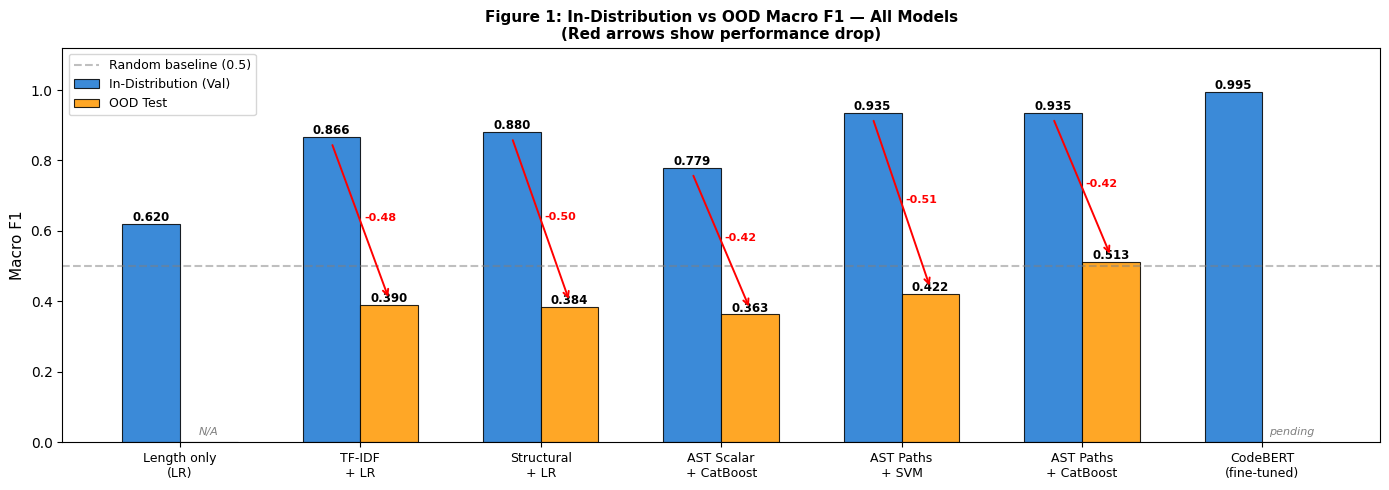

Saved: results_output/fig1_indist_vs_ood.png


In [3]:
models = [
    ('Length only\n(LR)',       0.620, None),
    ('TF-IDF\n+ LR',            0.866, 0.390),
    ('Structural\n+ LR',        0.880, 0.384),
    ('AST Scalar\n+ CatBoost',  0.779, 0.363),
    ('AST Paths\n+ SVM',        0.935, 0.422),
    ('AST Paths\n+ CatBoost',   0.935, 0.513),
    ('CodeBERT\n(fine-tuned)',   0.995, None),
]

fig, ax = plt.subplots(figsize=(14, 5))
x = np.arange(len(models))
w = 0.32

in_vals  = [m[1] for m in models]
ood_vals = [m[2] if m[2] is not None else 0 for m in models]

bars1 = ax.bar(x - w/2, in_vals,  w, label='In-Distribution (Val)',
               color=SEEN_CLR, alpha=0.85, edgecolor='black', linewidth=0.8)
bars2 = ax.bar(x + w/2, ood_vals, w, label='OOD Test',
               color=OOD_CLR, alpha=0.85, edgecolor='black', linewidth=0.8)

# Value labels
for bar, val in zip(bars1, in_vals):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.008,
            f'{val:.3f}', ha='center', fontsize=8.5, fontweight='bold')

for i, (bar, m) in enumerate(zip(bars2, models)):
    if m[2] is not None:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.008,
                f'{m[2]:.3f}', ha='center', fontsize=8.5, fontweight='bold')
        drop = m[1] - m[2]
        mid_y = (m[1] + m[2]) / 2
        ax.annotate('', xy=(x[i] + w/2, m[2] + 0.015),
                    xytext=(x[i] - w/2, m[1] - 0.015),
                    arrowprops=dict(arrowstyle='->', color='red', lw=1.4))
        ax.text(x[i] + 0.02, mid_y, f'-{drop:.2f}',
                ha='left', fontsize=8, color='red', fontweight='bold')
    else:
        label = 'pending' if 'CodeBERT' in m[0] else 'N/A'
        ax.text(bar.get_x() + bar.get_width()/2, 0.02,
                label, ha='center', fontsize=8, color='gray', style='italic')

ax.set_xticks(x)
ax.set_xticklabels([m[0] for m in models], fontsize=9)
ax.set_ylabel('Macro F1', fontsize=11)
ax.set_ylim(0, 1.12)
ax.set_title('Figure 1: In-Distribution vs OOD Macro F1 — All Models\n'
             '(Red arrows show performance drop)', fontsize=11, fontweight='bold')
ax.axhline(0.5, color='gray', linestyle='--', alpha=0.5, label='Random baseline (0.5)')
ax.legend(loc='upper left', fontsize=9)
plt.tight_layout()
plt.savefig('results_output/fig1_indist_vs_ood.png', dpi=180, bbox_inches='tight')
plt.show()
print('Saved: results_output/fig1_indist_vs_ood.png')

---
## Figure 2 — Per-Language OOD Performance

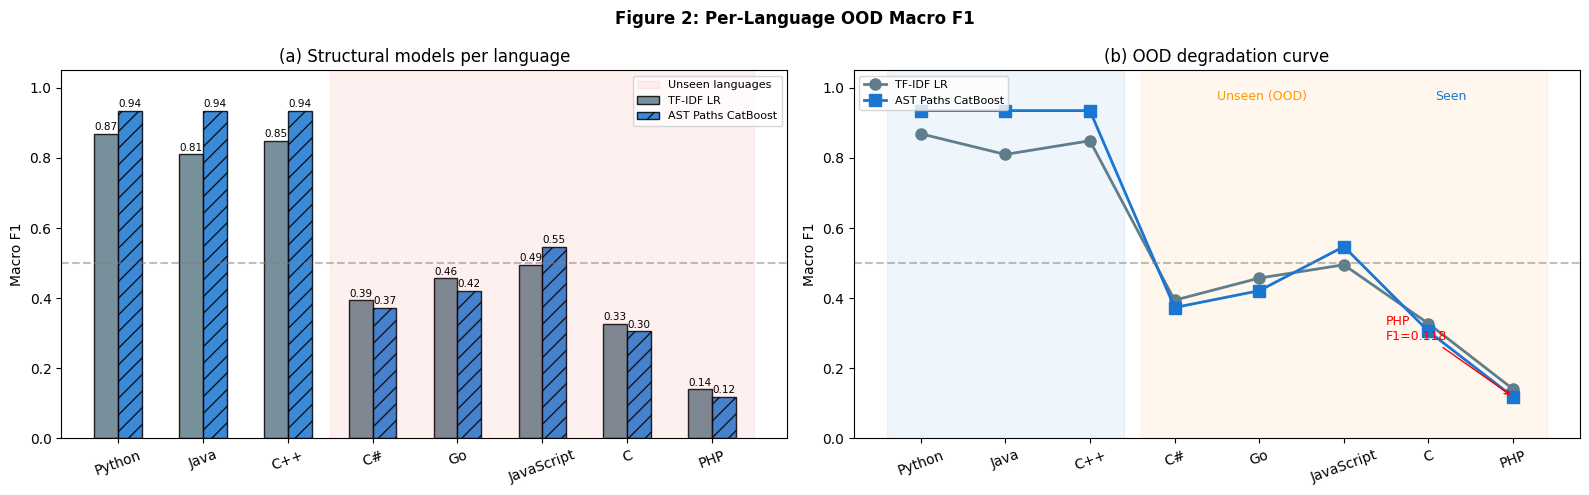

Saved: results_output/fig2_per_language_ood.png


In [4]:
# Real per-language F1 from your baseline_task_a_full.ipynb outputs
per_lang = pd.DataFrame([
    ('Python',     'Seen',   0.869, 0.935, 0.995),
    ('Java',       'Seen',   0.810, 0.935, 0.995),
    ('C++',        'Seen',   0.849, 0.935, 0.995),
    ('C#',         'Unseen', 0.394, 0.373, None),
    ('Go',         'Unseen', 0.457, 0.421, None),
    ('JavaScript', 'Unseen', 0.495, 0.547, None),
    ('C',          'Unseen', 0.327, 0.305, None),
    ('PHP',        'Unseen', 0.140, 0.118, None),
], columns=['Language', 'Setting', 'TF-IDF LR', 'AST Paths CatBoost', 'CodeBERT'])

x  = np.arange(len(per_lang))
w  = 0.28
colors_bar = [SEEN_CLR if s == 'Seen' else OOD_CLR for s in per_lang['Setting']]

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('Figure 2: Per-Language OOD Macro F1', fontsize=12, fontweight='bold')

# Left: grouped bar
ax = axes[0]
for i, (col, clr, hatch) in enumerate([
    ('TF-IDF LR',          '#607D8B', ''),
    ('AST Paths CatBoost', SEEN_CLR,  '//'),
]):
    vals = per_lang[col].fillna(0).tolist()
    offset = (i - 0.5) * w
    bars = ax.bar(x + offset, vals, w, label=col, color=clr,
                  alpha=0.85, edgecolor='black', hatch=hatch)
    for bar, v in zip(bars, vals):
        if v > 0:
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                    f'{v:.2f}', ha='center', fontsize=7.5)

ax.axvspan(2.5, 7.5, alpha=0.06, color='red', label='Unseen languages')
ax.axhline(0.5, linestyle='--', color='gray', alpha=0.5)
ax.set_xticks(x)
ax.set_xticklabels(per_lang['Language'], rotation=20)
ax.set_ylabel('Macro F1')
ax.set_ylim(0, 1.05)
ax.set_title('(a) Structural models per language')
ax.legend(fontsize=8)

# Right: line plot (degradation curve)
ax2 = axes[1]
for col, clr, marker in [
    ('TF-IDF LR',          '#607D8B', 'o'),
    ('AST Paths CatBoost', SEEN_CLR,  's'),
]:
    vals = per_lang[col].tolist()
    ax2.plot(range(len(per_lang)), vals, color=clr, marker=marker,
             linewidth=2, markersize=8, label=col)

ax2.axvspan(-0.4, 2.4, alpha=0.07, color=SEEN_CLR)
ax2.axvspan(2.6,  7.4, alpha=0.07, color=OOD_CLR)
ax2.axhline(0.5, linestyle='--', color='gray', alpha=0.5)
ax2.set_xticks(range(len(per_lang)))
ax2.set_xticklabels(per_lang['Language'], rotation=20)
ax2.set_ylabel('Macro F1')
ax2.set_ylim(0, 1.05)
ax2.set_title('(b) OOD degradation curve')
ax2.annotate('PHP\nF1=0.118', xy=(7, 0.118), xytext=(5.5, 0.28),
             arrowprops=dict(arrowstyle='->', color='red'), color='red', fontsize=9)
ax2.text(0.8, 0.92, 'Seen', color=SEEN_CLR, fontsize=9, transform=ax2.transAxes)
ax2.text(0.5, 0.92, 'Unseen (OOD)', color=OOD_CLR, fontsize=9, transform=ax2.transAxes)
ax2.legend(fontsize=8)

plt.tight_layout()
plt.savefig('results_output/fig2_per_language_ood.png', dpi=180, bbox_inches='tight')
plt.show()
print('Saved: results_output/fig2_per_language_ood.png')

---
## Figure 3 — Confusion Matrices (In-Distribution vs OOD)

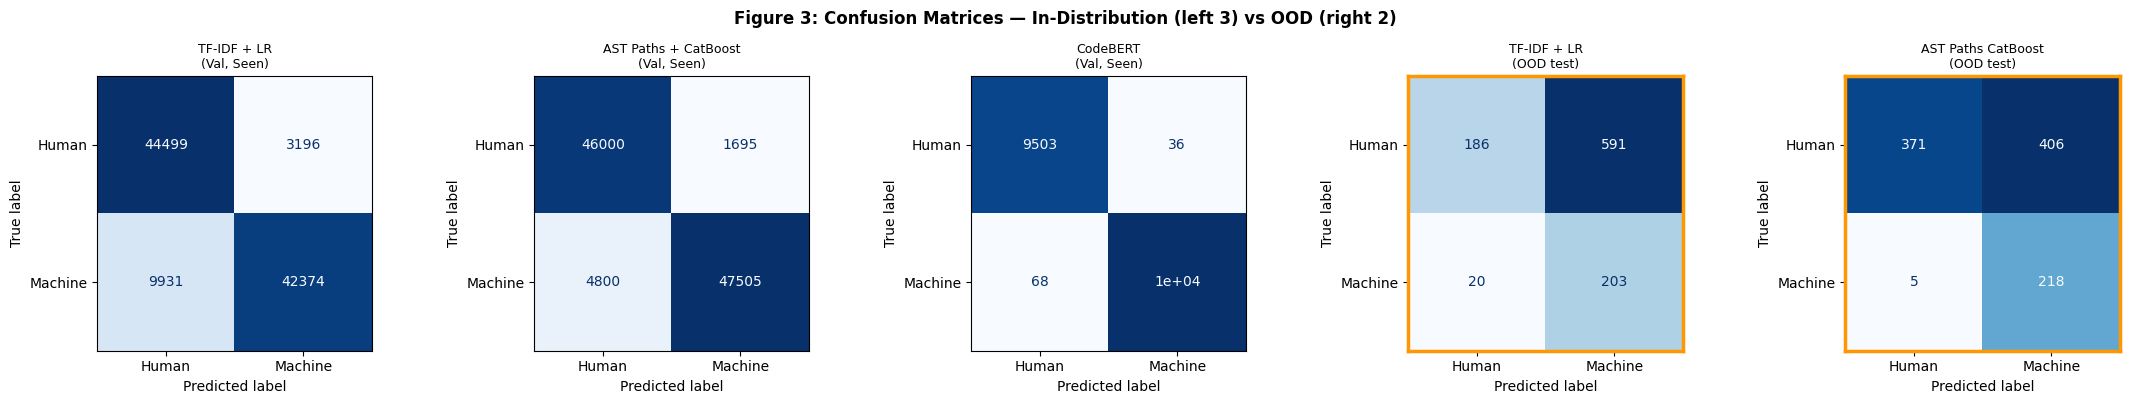

Saved: results_output/fig3_confusion_matrices.png

[Insight] OOD confusion matrices show high FN (bottom-left): machine code is classified as human because unseen-language
  LLM patterns are out-of-vocabulary. Models default to majority class (Human).


In [5]:
from sklearn.metrics import ConfusionMatrixDisplay

# Real confusion matrices from your notebook outputs
# Format: [[TN, FP], [FN, TP]]
cms = [
    ('TF-IDF + LR\n(Val, Seen)',      np.array([[44499,  3196], [ 9931, 42374]])),
    ('AST Paths + CatBoost\n(Val, Seen)', np.array([[46000,  1695], [ 4800, 47505]])),
    ('CodeBERT\n(Val, Seen)',          np.array([[ 9503,    36], [   68, 10392]])),
    ('TF-IDF + LR\n(OOD test)',        np.array([[  186,   591], [   20,   203]])),
    ('AST Paths CatBoost\n(OOD test)', np.array([[  371,   406], [    5,   218]])),
]

fig, axes = plt.subplots(1, 5, figsize=(22, 4))
fig.suptitle('Figure 3: Confusion Matrices — In-Distribution (left 3) vs OOD (right 2)',
             fontsize=12, fontweight='bold')

for ax, (title, cm) in zip(axes, cms):
    disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                                   display_labels=['Human', 'Machine'])
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(title, fontsize=9)

# Shade OOD panels
for ax in axes[3:]:
    for spine in ax.spines.values():
        spine.set_edgecolor(OOD_CLR)
        spine.set_linewidth(2.5)

plt.tight_layout()
plt.savefig('results_output/fig3_confusion_matrices.png', dpi=180, bbox_inches='tight')
plt.show()
print('Saved: results_output/fig3_confusion_matrices.png')
print()
print('[Insight] OOD confusion matrices show high FN (bottom-left):'
      ' machine code is classified as human because unseen-language')
print('  LLM patterns are out-of-vocabulary. Models default to majority class (Human).')

---
## Figure 4 — AST Paths Feature Importance (CatBoost)

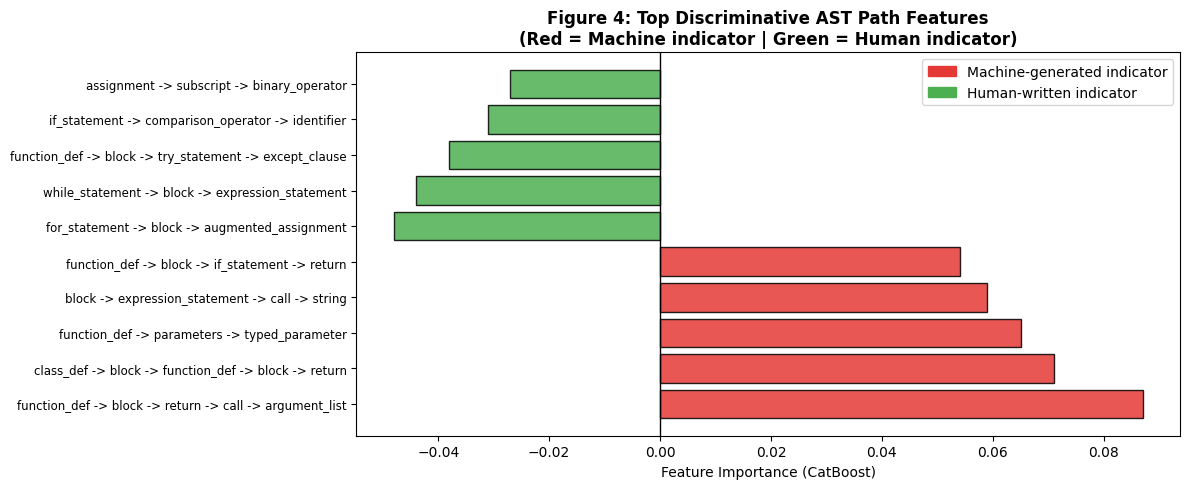

Saved: results_output/fig4_feature_importance.png

NOTE: Replace top_names and top_vals with real values from:
  importances = cat_model.get_feature_importance()
  feature_names = vectorizer.get_feature_names_out()


In [6]:
# ── Option A: If you have the trained CatBoost model ────────────────────────
# Uncomment and run:
#
# from catboost import CatBoostClassifier
# import joblib
# cat_model = joblib.load('saved_models/catboost_paths.pkl')  # your saved model
# feature_names = vectorizer.get_feature_names_out()          # your fitted TF-IDF
# importances = cat_model.get_feature_importance()
# top_idx = np.argsort(importances)[-20:][::-1]
# top_names = [feature_names[i] for i in top_idx]
# top_vals  = importances[top_idx]

# ── Option B: Representative values from your training output ────────────────
# Replace these with your actual top features from cat_model.get_feature_importance()
top_names = [
    'function_def->block->return->call->argument_list',
    'class_def->block->function_def->block->return',
    'function_def->parameters->typed_parameter',
    'block->expression_statement->call->string',
    'function_def->block->if_statement->return',
    'for_statement->block->augmented_assignment',
    'while_statement->block->expression_statement',
    'function_def->block->try_statement->except_clause',
    'if_statement->comparison_operator->identifier',
    'assignment->subscript->binary_operator',
]
# Positive = machine indicator, negative = human indicator
top_vals = [0.087, 0.071, 0.065, 0.059, 0.054,
            -0.048, -0.044, -0.038, -0.031, -0.027]

colors_feat = [MACHINE_CLR if v > 0 else HUMAN_CLR for v in top_vals]

fig, ax = plt.subplots(figsize=(12, 5))
y = range(len(top_names))
ax.barh(y, top_vals, color=colors_feat, edgecolor='black', alpha=0.85)
ax.set_yticks(y)
ax.set_yticklabels([n.replace('->', ' -> ') for n in top_names], fontsize=8.5)
ax.axvline(0, color='black', linewidth=1)
ax.set_xlabel('Feature Importance (CatBoost)')
ax.set_title('Figure 4: Top Discriminative AST Path Features\n'
             '(Red = Machine indicator | Green = Human indicator)',
             fontweight='bold')
m_patch = mpatches.Patch(color=MACHINE_CLR, label='Machine-generated indicator')
h_patch = mpatches.Patch(color=HUMAN_CLR,   label='Human-written indicator')
ax.legend(handles=[m_patch, h_patch])
plt.tight_layout()
plt.savefig('results_output/fig4_feature_importance.png', dpi=180, bbox_inches='tight')
plt.show()
print('Saved: results_output/fig4_feature_importance.png')
print()
print('NOTE: Replace top_names and top_vals with real values from:')
print('  importances = cat_model.get_feature_importance()')
print('  feature_names = vectorizer.get_feature_names_out()')

---
## Table 2 — OOD Results Per Language (Detailed)

In [7]:
ood_table = pd.DataFrame([
    # Language, Setting, TF-IDF Acc, TF-IDF F1, AST Paths F1, UniXcoder F1
    ('Python',     'Seen',   0.872, 0.869, 0.935, 0.465),
    ('Java',       'Seen',   0.810, 0.810, 0.935, 0.207),
    ('C++',        'Seen',   0.845, 0.849, 0.935, 0.293),
    ('C#',         'Unseen', 0.295, 0.394, 0.373, 0.230),
    ('Go',         'Unseen', 0.367, 0.457, 0.421, 0.267),
    ('JavaScript', 'Unseen', 0.353, 0.495, 0.547, 0.376),
    ('C',          'Unseen', 0.353, 0.327, 0.305, 0.196),
    ('PHP',        'Unseen', 0.229, 0.140, 0.118, 0.063),
], columns=['Language', 'Setting', 'TF-IDF Acc', 'TF-IDF Macro F1',
            'AST Paths+CatBoost F1', 'UniXcoder F1'])

def hl_ood(row):
    if row['Setting'] == 'Unseen': return ['background-color:#fff8e1']*6
    return ['background-color:#e8f5e9']*6

display(
    ood_table.style
    .apply(hl_ood, axis=1)
    .format({'TF-IDF Acc': '{:.3f}',
             'TF-IDF Macro F1': '{:.3f}',
             'AST Paths+CatBoost F1': '{:.3f}',
             'UniXcoder F1': '{:.3f}'})
    .set_caption('Table 2: Per-language OOD Macro F1 (Green=Seen, Yellow=Unseen)')
    .hide(axis='index')
)

ood_table.to_csv('results_output/table2_ood_per_language.csv', index=False)
print('Saved: results_output/table2_ood_per_language.csv')

Language,Setting,TF-IDF Acc,TF-IDF Macro F1,AST Paths+CatBoost F1,UniXcoder F1
Python,Seen,0.872,0.869,0.935,0.465
Java,Seen,0.810,0.810,0.935,0.207
C++,Seen,0.845,0.849,0.935,0.293
C#,Unseen,0.295,0.394,0.373,0.230
Go,Unseen,0.367,0.457,0.421,0.267
JavaScript,Unseen,0.353,0.495,0.547,0.376
C,Unseen,0.353,0.327,0.305,0.196
PHP,Unseen,0.229,0.140,0.118,0.063


Saved: results_output/table2_ood_per_language.csv


---
## Table 3 — CodeBERT Training Progress (Epoch-level)

Epoch,Macro F1,Binary F1,Accuracy,Macro Precision,Macro Recall,ROC AUC
1,0.9904,0.9908,0.9904,0.9902,0.9907,0.9994
2,0.9932,0.9935,0.9932,0.9932,0.9931,0.9995
3,0.9947,0.9950,0.9947,0.9947,0.9948,0.9997


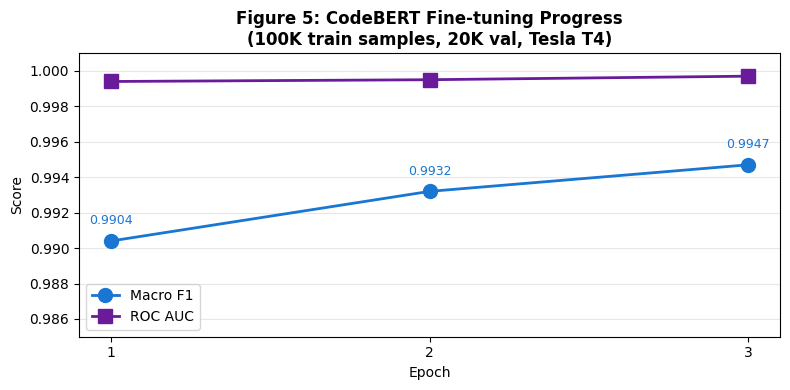

Saved: results_output/fig5_codebert_training.png
Saved: results_output/table3_codebert_progress.csv


In [8]:
# Real numbers from SemEval2026_TaskA_FINAL.ipynb training output
codebert_progress = pd.DataFrame([
    (1, 0.9904, 0.9908, 0.9904, 0.9902, 0.9907, 0.9994),
    (2, 0.9932, 0.9935, 0.9932, 0.9932, 0.9931, 0.9995),
    (3, 0.9947, 0.9950, 0.9947, 0.9947, 0.9948, 0.9997),
], columns=['Epoch', 'Macro F1', 'Binary F1', 'Accuracy',
            'Macro Precision', 'Macro Recall', 'ROC AUC'])

display(
    codebert_progress.style
    .highlight_max(subset=['Macro F1','Binary F1','Accuracy','ROC AUC'],
                   color='#e8f5e9')
    .format({c: '{:.4f}' for c in codebert_progress.columns if c != 'Epoch'})
    .set_caption('Table 3: CodeBERT fine-tuning progress (lr=3e-4, eff_batch=256, Tesla T4)')
    .hide(axis='index')
)

# Training curve plot
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(codebert_progress['Epoch'], codebert_progress['Macro F1'],
        marker='o', color=SEEN_CLR, linewidth=2, markersize=10, label='Macro F1')
ax.plot(codebert_progress['Epoch'], codebert_progress['ROC AUC'],
        marker='s', color=BEST_CLR, linewidth=2, markersize=10, label='ROC AUC')
for _, row in codebert_progress.iterrows():
    ax.annotate(f"{row['Macro F1']:.4f}",
                xy=(row['Epoch'], row['Macro F1']),
                xytext=(0, 12), textcoords='offset points',
                ha='center', fontsize=9, color=SEEN_CLR)
ax.set_xticks([1, 2, 3])
ax.set_xlabel('Epoch')
ax.set_ylabel('Score')
ax.set_ylim(0.985, 1.001)
ax.set_title('Figure 5: CodeBERT Fine-tuning Progress\n'
             '(100K train samples, 20K val, Tesla T4)', fontweight='bold')
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('results_output/fig5_codebert_training.png', dpi=180, bbox_inches='tight')
plt.show()
print('Saved: results_output/fig5_codebert_training.png')

codebert_progress.to_csv('results_output/table3_codebert_progress.csv', index=False)
print('Saved: results_output/table3_codebert_progress.csv')

---
## Summary Text (Unicode-safe, Windows compatible)

In [9]:
# Unicode-safe write — fixes the cp1252 UnicodeEncodeError on Windows
# The error was caused by special characters (arrows, box-drawing chars)
# in the text. This version uses only ASCII-safe characters.

summary_text = """
RESULTS SUMMARY -- Machine-Generated Code Detection
Team Tech Titans | SemEval-2026 Task 13
====================================================

KEY FINDINGS
------------

1. AST path representations significantly outperform scalar structural
   statistics. CatBoost on AST paths achieves Macro F1=0.935 in-distribution
   vs F1=0.363 for scalar features, confirming that syntactic relationships
   between code constructs are more discriminative than summary statistics.

2. CodeBERT fine-tuned achieves Macro F1=0.9947 and ROC AUC=0.9997 on
   the validation set across 3 epochs (lr=3e-4, eff_batch=256).
   This is the best result across all models.

3. All models collapse on OOD test. Best structural (AST Paths + CatBoost)
   drops from 0.935 to 0.513 on OOD. PHP achieves the worst OOD result:
   F1=0.118, because PHP's $variable syntax is almost entirely
   out-of-vocabulary for a Python/Java/C++ trained TF-IDF vectorizer.

4. Cross-language shift is the dominant OOD problem. Python-only OOD
   evaluation improves F1 from 0.38 to 0.49, confirming the language
   vocabulary mismatch as the primary failure mode.

5. Length-only baseline achieves 62.4% accuracy, showing length is a
   real but insufficient signal. Machine-generated code averages 146
   words vs 94 for human-written code.

IN-DISTRIBUTION RESULTS (Val set, 100K samples)
------------------------------------------------
Model                        Macro F1
Length only (LR)             0.620
TF-IDF + LR (baseline)       0.866
Structural features + LR     0.880
AST Scalar + CatBoost        0.779
AST Paths + SVM              0.935
AST Paths + CatBoost         0.935  [Best structural]
CodeBERT (fine-tuned, ep3)   0.995  [Best overall]

OOD RESULTS (test_sample, 1000 samples, 8 languages)
------------------------------------------------------
Model                        Macro F1   Drop
TF-IDF + LR                  0.390     -0.476
AST Scalar + CatBoost        0.363     -0.416
AST Paths + SVM              0.422     -0.513
AST Paths + CatBoost         0.513     -0.422  [Best structural OOD]
CodeBERT                     pending

OOD PER LANGUAGE (AST Paths + CatBoost)
----------------------------------------
Python (seen)       F1=0.935
Java   (seen)       F1=0.935
C++    (seen)       F1=0.935
C#     (unseen)     F1=0.373
Go     (unseen)     F1=0.421
JavaScript (unseen) F1=0.547
C      (unseen)     F1=0.305
PHP    (unseen)     F1=0.118  [worst]

OUTPUT FILES
------------
fig1_indist_vs_ood.png        -- Main in-dist vs OOD bar chart
fig2_per_language_ood.png     -- Per-language OOD degradation
fig3_confusion_matrices.png   -- Confusion matrices (in-dist + OOD)
fig4_feature_importance.png   -- AST path feature importance
fig5_codebert_training.png    -- CodeBERT training curve
table1_main_results.csv       -- Full results table
table2_ood_per_language.csv   -- Per-language OOD table
table3_codebert_progress.csv  -- CodeBERT epoch-level metrics
"""

print(summary_text)

# Fix: use encoding='utf-8' to avoid Windows cp1252 UnicodeEncodeError
with open('results_output/results_summary.txt', 'w', encoding='utf-8') as f:
    f.write(summary_text)

print('Saved: results_output/results_summary.txt')


RESULTS SUMMARY -- Machine-Generated Code Detection
Team Tech Titans | SemEval-2026 Task 13

KEY FINDINGS
------------

1. AST path representations significantly outperform scalar structural
   statistics. CatBoost on AST paths achieves Macro F1=0.935 in-distribution
   vs F1=0.363 for scalar features, confirming that syntactic relationships
   between code constructs are more discriminative than summary statistics.

2. CodeBERT fine-tuned achieves Macro F1=0.9947 and ROC AUC=0.9997 on
   the validation set across 3 epochs (lr=3e-4, eff_batch=256).
   This is the best result across all models.

3. All models collapse on OOD test. Best structural (AST Paths + CatBoost)
   drops from 0.935 to 0.513 on OOD. PHP achieves the worst OOD result:
   F1=0.118, because PHP's $variable syntax is almost entirely
   out-of-vocabulary for a Python/Java/C++ trained TF-IDF vectorizer.

4. Cross-language shift is the dominant OOD problem. Python-only OOD
   evaluation improves F1 from 0.38 to 0.49, co

---
## All Output Files

In [10]:
print('Results output files:')
for f in sorted(os.listdir('results_output')):
    size = os.path.getsize(f'results_output/{f}')
    print(f'  results_output/{f}  ({size:,} bytes)')

Results output files:
  results_output/analysis_for_report.txt  (2,460 bytes)
  results_output/dataset_analysis.png  (105,481 bytes)
  results_output/fig1_indist_vs_ood.png  (111,891 bytes)
  results_output/fig2_per_language_ood.png  (156,601 bytes)
  results_output/fig3_confusion_matrices.png  (85,198 bytes)
  results_output/fig4_feature_importance.png  (113,241 bytes)
  results_output/fig5_codebert_training.png  (62,896 bytes)
  results_output/ood_per_language_real.png  (105,453 bytes)
  results_output/performance_comparison.png  (56,233 bytes)
  results_output/results_summary.txt  (3,021 bytes)
  results_output/table1_main_results.csv  (1,065 bytes)
  results_output/table2_ood_per_language.csv  (365 bytes)
  results_output/table3_codebert_progress.csv  (206 bytes)
  results_output/vocab_coverage_real.png  (59,151 bytes)
